## Design

Each trial has three relevant time windows:

```
    [  fixation baseline  ]  [  pre-disclosure  ]   [ post-disclosure ]
```

- **Fixation RMSSD**: neutral baseline immediately before the song (participant fixates on a plus sign).
- **Pre-disclosure RMSSD**: HRV while listening, *before* the origin label appears.
- **Post-disclosure RMSSD**: HRV while listening, *after* the origin label appears.

The period before fixation starts and after `song_listen_finished` is **excluded** from all analyses.

### Baseline-corrected deltas (within-participant, within-trial)
- **ΔRMSSD_pre**  = RMSSD_pre  − RMSSD_fixation
- **ΔRMSSD_post** = RMSSD_post − RMSSD_fixation

These deltas remove between-participant differences in resting HRV and slow drift,
leaving only the trial-specific change relative to that trial's own fixation baseline.

### ECG timestamp note
All timestamps are converted to UTC unix seconds before aligning with events.

In [1]:
import sys
import os
import glob
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from tqdm import tqdm

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('ecg_utils.py')))
from ecg_utils import load_ecg_csv, extract_ecg_segment, compute_rmssd_from_raw, compute_sampling_rate

REPO_ROOT      = os.path.abspath('..')
PARTICIPANTS_CSV = os.path.join(REPO_ROOT, 'experiment', 'data_anonymized', 'participants.csv')
EVENTS_CSV     = os.path.join(REPO_ROOT, 'experiment', 'data_anonymized', 'events.csv')
ECG_DIR        = os.path.join(REPO_ROOT, 'experiment', 'data_anonymized', 'ecg_recordings')
OUT_DIR        = os.path.join(REPO_ROOT, 'analysis', 'results')

# Physiologically implausible RMSSD threshold (ms).
# Trials where any period exceeds this are flagged as likely ECG artifact.
RMSSD_MAX_MS = 150

print('REPO_ROOT    :', REPO_ROOT)
print('EVENTS_CSV   :', EVENTS_CSV)
print('ECG_DIR      :', ECG_DIR)

REPO_ROOT    : /Users/hana/ai-music-origin-ecg-study
EVENTS_CSV   : /Users/hana/ai-music-origin-ecg-study/experiment/data_anonymized/events.csv
ECG_DIR      : /Users/hana/ai-music-origin-ecg-study/experiment/data_anonymized/ecg_recordings


## 2. Load Events and Extract Trial Windows

In [2]:
events = pd.read_csv(EVENTS_CSV)
participants = pd.read_csv(PARTICIPANTS_CSV)

# Remove invalid participants
participants = participants[participants['valid_participant']]

# Remove invalid participants from events
events = events[events['participant_id'].isin(participants['participant_id'])]

# convert local_time to unix_seconds
events['unix_seconds'] = events['local_time'].apply(lambda x: pd.Timestamp(x).timestamp()).astype(float)

# Main-phase, trial-level events only
main_events = events[(events['phase'] == 'main') & events['trial_index'].notna()].copy()
main_events['trial_index'] = main_events['trial_index'].astype(int)

KEY_EVENTS = [
    'fixation_started', 'fixation_finished',
    'song_listen_started', 'origin_shown', 'song_listen_finished'
]

pivoted = (
    main_events[main_events['event'].isin(KEY_EVENTS)]
    .pivot_table(
        index=['participant_id', 'trial_index', 'song_file', 'mislabeled'],
        columns='event',
        values='unix_seconds',
        aggfunc='first'
    )
    .reset_index()
)
pivoted.columns.name = None

for col in KEY_EVENTS:
    if col not in pivoted.columns:
        pivoted[col] = np.nan

pivoted['song'] = pivoted['song_file'].str.extract(r'/([^/]+)\.mp3$')

print(f'Total trials (all participants): {len(pivoted)}')
print(f'Unique participants            : {pivoted["participant_id"].nunique()}')
pivoted.head(6)

Total trials (all participants): 126
Unique participants            : 21


,participant_id,trial_index,song_file,mislabeled,fixation_finished,fixation_started,origin_shown,song_listen_finished,song_listen_started,song
0,25DLWY,1,stimuli/experiment/warm-light-patio.mp3,False,1.781710e+09,1.781710e+09,1.781710e+09,1.781710e+09,1.781710e+09,warm-light-patio
1,25DLWY,2,stimuli/experiment/violins-&-sand.mp3,True,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,violins-&-sand
2,25DLWY,3,stimuli/experiment/old-blue-sheet.mp3,True,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,old-blue-sheet
3,25DLWY,4,stimuli/experiment/guitar-vinaigrette.mp3,False,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,1.781711e+09,guitar-vinaigrette
4,25DLWY,5,stimuli/experiment/sun-through-blinds.mp3,True,1.781711e+09,1.781711e+09,1.781711e+09,1.781712e+09,1.781711e+09,sun-through-blinds
5,25DLWY,6,stimuli/experiment/red-motel-key.mp3,False,1.781712e+09,1.781712e+09,1.781712e+09,1.781712e+09,1.781712e+09,red-motel-key


## 3. Load ECG Files Indexed by Participant ID

In [3]:
ecg_by_pid = {}

for path in tqdm(sorted(glob.glob(os.path.join(ECG_DIR, 'ECG_*.csv')))):
    t, ecg, df = load_ecg_csv(path)
    sr = compute_sampling_rate(t)

    # convert sample_datetime to unix_seconds
    df["unix_seconds"] = df["sample_datetime"].apply(lambda x: pd.Timestamp(x).timestamp()).astype(float)

    fname = os.path.splitext(os.path.basename(path))[0]
    pid = fname.split('_')[1]
    ecg_by_pid[pid] = {
        'file': fname,
        'pid':  pid,
        'sampling_rate': sr,
        'df': df
    }

print(f'\nLoaded {len(ecg_by_pid)} ECG file(s).')

100%|██████████| 23/23 [00:06<00:00,  3.64it/s]


Loaded 23 ECG file(s).


## 4. Compute RMSSD for Each Trial × Period

In [4]:
records = []

for _, row in pivoted.iterrows():
    t_fix_start  = row['fixation_started']
    t_fix_end    = row['fixation_finished']    # ≈ song_listen_started
    t_song_start = row['song_listen_started']
    t_origin     = row['origin_shown']
    t_song_end   = row['song_listen_finished']

    # Skip if any critical timestamp is missing
    if any(pd.isna(v) for v in [t_fix_start, t_fix_end, t_song_start, t_origin, t_song_end]):
        continue

    pid         = row['participant_id']
    ecg_entry   = ecg_by_pid[pid]
    df_ecg      = ecg_entry['df']
    sr          = ecg_entry['sampling_rate']

    # ignore if the ECG file is not found
    if df_ecg is None:
        print(f"ECG file not found for participant {pid}")
        continue

    seg_fix  = extract_ecg_segment(df_ecg, t_fix_start,  t_fix_end)
    seg_pre  = extract_ecg_segment(df_ecg, t_song_start, t_origin)
    seg_post = extract_ecg_segment(df_ecg, t_origin,     t_song_end)

    rmssd_fix  = compute_rmssd_from_raw(seg_fix,  sr)
    rmssd_pre  = compute_rmssd_from_raw(seg_pre,  sr)
    rmssd_post = compute_rmssd_from_raw(seg_post, sr)

    artifact = any(v > RMSSD_MAX_MS for v in [rmssd_fix, rmssd_pre, rmssd_post] if not np.isnan(v))

    records.append({
        'participant_id': pid,
        'trial_index':    row['trial_index'],
        'song':           row['song'],
        'mislabeled':     row['mislabeled'],
        'dur_fixation_s': round(t_fix_end   - t_fix_start,  1),
        'dur_pre_s':      round(t_origin     - t_song_start, 1),
        'dur_post_s':     round(t_song_end   - t_origin,     1),
        'rmssd_fixation': rmssd_fix,
        'rmssd_pre':      rmssd_pre,
        'rmssd_post':     rmssd_post,
        'artifact':       artifact,
    })

results = pd.DataFrame(records)
results['delta_rmssd_pre']  = results['rmssd_pre']  - results['rmssd_fixation']
results['delta_rmssd_post'] = results['rmssd_post'] - results['rmssd_fixation']

print(f'Trials            : {len(results)}')
print(f'Valid fixation    : {results["rmssd_fixation"].notna().sum()}')
print(f'Valid pre         : {results["rmssd_pre"].notna().sum()}')
print(f'Valid post        : {results["rmssd_post"].notna().sum()}')
print(f'Artifact-flagged  : {results["artifact"].sum()}')

Trials            : 126
Valid fixation    : 126
Valid pre         : 126
Valid post        : 126
Artifact-flagged  : 1


## 5. Full Results Table

In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 35)

display_cols = [
    'participant_id', 'trial_index', 'song', 'mislabeled',
    'dur_fixation_s', 'dur_pre_s', 'dur_post_s',
    'rmssd_fixation', 'rmssd_pre', 'rmssd_post',
    'delta_rmssd_pre', 'delta_rmssd_post',
    'artifact',
]

results[display_cols].sort_values(['participant_id', 'trial_index']).head(10)

,participant_id,trial_index,song,mislabeled,dur_fixation_s,dur_pre_s,dur_post_s,rmssd_fixation,rmssd_pre,rmssd_post,delta_rmssd_pre,delta_rmssd_post,artifact
0,25DLWY,1,warm-light-patio,False,30.00,81.00,82.20,22.00,19.98,18.10,-2.02,-3.90,False
1,25DLWY,2,violins-&-sand,True,30.00,107.20,108.50,21.53,20.92,18.92,-0.61,-2.62,False
2,25DLWY,3,old-blue-sheet,True,30.00,97.00,98.20,24.18,21.81,20.51,-2.36,-3.66,False
3,25DLWY,4,guitar-vinaigrette,False,30.00,103.10,104.30,24.21,19.00,18.00,-5.21,-6.21,False
4,25DLWY,5,sun-through-blinds,True,30.00,108.50,109.50,23.26,18.58,17.81,-4.68,-5.45,False
5,25DLWY,6,red-motel-key,False,30.00,139.20,140.30,19.06,18.95,19.84,-0.11,0.78,False
6,37X57U,1,sun-through-blinds,True,30.00,108.50,109.80,29.27,18.74,18.46,-10.53,-10.80,False
7,37X57U,2,guitar-vinaigrette,False,30.00,103.10,104.20,24.76,16.96,17.28,-7.80,-7.48,False
8,37X57U,3,old-blue-sheet,True,30.00,97.00,98.40,20.58,12.39,17.01,-8.18,-3.57,False
9,37X57U,4,violins-&-sand,False,30.00,107.20,108.20,18.98,17.41,13.71,-1.57,-5.27,False


## 6. Artifact-flagged Trials

In [6]:
artifact_rows = results[results['artifact'] == True]
print(f'Artifact-flagged trials (any RMSSD > {RMSSD_MAX_MS} ms): {len(artifact_rows)}')
if len(artifact_rows):
    display(artifact_rows[['participant_id', 'trial_index', 'song',
                             'rmssd_fixation', 'rmssd_pre', 'rmssd_post']])

Artifact-flagged trials (any RMSSD > 150 ms): 1


,participant_id,trial_index,song,rmssd_fixation,rmssd_pre,rmssd_post
83,NVTK75,6,red-motel-key,155.07,36.59,34.52


## 7. Group-Level Summary: Correct vs. Mislabeled Trials

Only trials with **all three** valid RMSSD values are included.  
Artifact-flagged trials are excluded from the **clean** analysis.

- **Correct label** (`mislabeled = False`): shown origin matches true origin.
- **Mislabeled** (`mislabeled = True`): shown origin is wrong.

In [7]:
valid_all   = results.dropna(subset=['rmssd_fixation', 'rmssd_pre', 'rmssd_post']).copy()
valid_clean = valid_all[~valid_all['artifact']].copy()

for label, df_v in [('ALL valid trials', valid_all),
                     (f'CLEAN (RMSSD ≤ {RMSSD_MAX_MS} ms)', valid_clean)]:
    df_v['label_condition'] = df_v['mislabeled'].map({True: 'Mislabeled', False: 'Correct label'})
    summary = (
        df_v.groupby('label_condition')[['delta_rmssd_pre', 'delta_rmssd_post']]
        .agg(['mean', 'std', 'count'])
        .round(2)
    )
    print(f'\n=== {label} (n={len(df_v)}) ===')
    print(summary)

valid_clean['label_condition'] = valid_clean['mislabeled'].map({True: 'Mislabeled', False: 'Correct label'})


=== ALL valid trials (n=126) ===
                delta_rmssd_pre             delta_rmssd_post            
                           mean   std count             mean   std count
label_condition                                                         
Correct label             -3.45 16.74    63            -4.31 17.67    63
Mislabeled                -3.14  7.09    63            -4.36  7.80    63

=== CLEAN (RMSSD ≤ 150 ms) (n=125) ===
                delta_rmssd_pre            delta_rmssd_post           
                           mean  std count             mean  std count
label_condition                                                       
Correct label             -1.59 8.02    62            -2.44 9.61    62
Mislabeled                -3.14 7.09    63            -4.36 7.80    63


## 8. Per-Song Summary (clean trials)

In [8]:
per_song = (
    valid_clean
    .groupby(['song', 'mislabeled'])
    [['rmssd_fixation', 'rmssd_pre', 'rmssd_post', 'delta_rmssd_pre', 'delta_rmssd_post']]
    .agg(['mean', 'std', 'count'])
    .round(2)
)
per_song

rmssd_fixation             rmssd_pre        \
                                        mean   std count      mean   std   
song               mislabeled                                              
guitar-vinaigrette False               33.69 12.03    11     29.67 11.59   
                   True                41.47 22.89    10     35.01 18.53   
old-blue-sheet     False               42.40 23.85    12     37.42 14.45   
                   True                30.83 14.63     9     29.21 13.44   
red-motel-key      False               30.29 10.51    10     30.14 11.10   
                   True                36.09 13.23    10     34.65 18.96   
sun-through-blinds False               29.09 10.43    10     29.93 13.27   
                   True                40.11 15.54    11     35.73 13.90   
violins-&-sand     False               39.20 18.89     8     38.71 19.62   
                   True                32.42 11.90    13     31.23 13.67   
warm-light-patio   False               34.70 14.02    11     34.90 16.54   
                   True                32.95 11.69    10     28.87 10.99   

                                    rmssd_post             delta_rmssd_pre  \
                              count       mean   std count            mean   
song               mislabeled                                                
guitar-vinaigrette False         11      31.39 13.73    11           -4.02   
                   True          10      34.01 15.72    10           -6.46   
old-blue-sheet     False         12      33.90 13.61    12           -4.99   
                   True           9      29.72 14.94     9           -1.62   
red-motel-key      False         10      30.39 11.10    10           -0.15   
                   True          10      31.75 14.33    10           -1.44   
sun-through-blinds False         10      29.71 13.89    10            0.84   
                   True          11      35.44 15.20    11           -4.39   
violins-&-sand     False          8      35.75 19.73     8           -0.49   
                   True          13      29.63 12.96    13           -1.19   
warm-light-patio   False         11      34.39 20.61    11            0.20   
                   True          10      27.07 10.03    10           -4.08   

                                          delta_rmssd_post              
                                std count             mean   std count  
song               mislabeled                                           
guitar-vinaigrette False       5.56    11            -2.31  6.01    11  
                   True        7.40    10            -7.46 12.75    10  
old-blue-sheet     False      14.39    12            -8.50 14.53    12  
                   True        4.78     9            -1.12  6.89     9  
red-motel-key      False       5.48    10             0.10  6.98    10  
                   True       11.17    10            -4.35  6.88    10  
sun-through-blinds False       6.07    10             0.62  6.47    10  
                   True        5.74    11            -4.68  5.25    11  
violins-&-sand     False       5.85     8            -3.45  7.47     8  
                   True        5.94    13            -2.79  6.56    13  
warm-light-patio   False       4.11    11            -0.31 10.42    11  
                   True        6.02    10            -5.88  7.18    10

## 9. Visualizations

### 9a. Absolute RMSSD across all three periods by label condition

In [9]:
melted = valid_clean.melt(
    id_vars=['participant_id', 'trial_index', 'song', 'label_condition'],
    value_vars=['rmssd_fixation', 'rmssd_pre', 'rmssd_post'],
    var_name='period', value_name='rmssd_ms'
)
melted['period'] = melted['period'].map({
    'rmssd_fixation': 'Fixation (baseline)',
    'rmssd_pre':      'Pre-disclosure',
    'rmssd_post':     'Post-disclosure'
})

period_order = ['Fixation (baseline)', 'Pre-disclosure', 'Post-disclosure']
cond_colors  = {'Correct label': '#4C9BE8', 'Mislabeled': '#E8754C'}

fig = go.Figure()
for cond, color in cond_colors.items():
    for period in period_order:
        subset = melted[(melted['label_condition'] == cond) & (melted['period'] == period)]['rmssd_ms']
        fig.add_trace(go.Box(
            y=subset, name=period,
            legendgroup=cond,
            legendgrouptitle_text=cond if period == 'Fixation (baseline)' else None,
            marker_color=color, boxmean=True, offsetgroup=cond,
        ))

fig.update_layout(
    title='Absolute RMSSD by Period and Label Condition (Artifact-flagged trials excluded)',
    yaxis_title='RMSSD (ms)', xaxis_title='Period',
    boxmode='group', template='plotly_white', height=500,
    legend=dict(groupclick='toggleitem')
)
fig.show()

### 9b. Baseline-corrected ΔRMSSD by label condition

In [10]:
delta_melted = valid_clean.melt(
    id_vars=['participant_id', 'trial_index', 'song', 'label_condition'],
    value_vars=['delta_rmssd_pre', 'delta_rmssd_post'],
    var_name='period', value_name='delta_rmssd_ms'
)
delta_melted['period'] = delta_melted['period'].map({
    'delta_rmssd_pre':  'Pre-disclosure',
    'delta_rmssd_post': 'Post-disclosure'
})

fig2 = go.Figure()
for cond, color in cond_colors.items():
    for period in ['Pre-disclosure', 'Post-disclosure']:
        subset = delta_melted[
            (delta_melted['label_condition'] == cond) & (delta_melted['period'] == period)
        ]['delta_rmssd_ms']
        fig2.add_trace(go.Box(
            y=subset, name=period,
            legendgroup=cond,
            legendgrouptitle_text=cond if period == 'Pre-disclosure' else None,
            marker_color=color, boxmean=True, offsetgroup=cond,
        ))

fig2.add_hline(y=0, line_dash='dash', line_color='gray', line_width=1)
fig2.update_layout(
    title='Baseline-corrected ΔRMSSD by Period and Label Condition (clean trials)',
    yaxis_title='ΔRMSSD (ms) relative to fixation baseline',
    xaxis_title='Period',
    boxmode='group', template='plotly_white', height=500,
    legend=dict(groupclick='toggleitem')
)
fig2.show()

### 9c. Per-participant ΔRMSSD post-disclosure strip chart

In [11]:
fig3 = px.strip(
    valid_clean.sort_values('participant_id'),
    x='participant_id', y='delta_rmssd_post',
    color='label_condition',
    color_discrete_map=cond_colors,
    hover_data=['song', 'participant_id'],
    title='Post-disclosure ΔRMSSD per participant and trial (Artifact-flagged trials excluded)',
    labels={'delta_rmssd_post': 'ΔRMSSD post (ms)', 'participant_id': 'Participant'},
    template='plotly_white', height=500
)
fig3.add_hline(y=0, line_dash='dash', line_color='gray', line_width=1)
fig3.update_layout(xaxis_tickangle=-40)
fig3.show()

### 9d. ΔRMSSD heatmap: participant × song (post-disclosure)

In [12]:
pivot_heat = valid_clean.pivot_table(
    index='participant_id', columns='song',
    values='delta_rmssd_post', aggfunc='mean'
)

fig4 = px.imshow(
    pivot_heat,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
    title='Post-disclosure ΔRMSSD heatmap (participant × song, Artifact-flagged trials excluded)',
    labels={'color': 'ΔRMSSD (ms)'},
    aspect='auto', template='plotly_white', height=500
)
fig4.show()

## 10. Participant Demographics: ΔRMSSD by Age Range and Nationality

Each point is one clean trial.  X-axes are participant-level demographic attributes merged from the participants table.  Color encodes label condition (correct vs. mislabeled).  The dashed grey line marks zero change from baseline.

### 10a. Post-disclosure ΔRMSSD by age range

In [13]:
# Merge demographics – normalise age-range dash variants (hyphen vs en-dash)
demo = participants[['participant_id', 'age', 'nationality']].copy()
demo['age'] = demo['age'].str.replace('–', '-', regex=False).str.strip()

df_demo = valid_clean.merge(demo, on='participant_id', how='left')

# Canonical age-band order (youngest → oldest; unknown last)
AGE_ORDER = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50+', 'Unknown']
age_present = [a for a in AGE_ORDER if a in df_demo['age'].dropna().unique()]

fig_age = px.strip(
    df_demo,
    x='age', y='delta_rmssd_post',
    color='label_condition',
    color_discrete_map={'Correct label': '#4C9BE8', 'Mislabeled': '#E8754C'},
    category_orders={'age': age_present},
    hover_data=['participant_id', 'song'],
    title='Post-disclosure ΔRMSSD by participant age range (clean trials)',
    labels={
        'delta_rmssd_post': 'ΔRMSSD post (ms)',
        'age': 'Age range',
        'label_condition': 'Label condition',
    },
    template='plotly_white',
    stripmode='overlay',
    height=450,
)
fig_age.update_traces(jitter=0.45, marker_size=7, opacity=0.75)
fig_age.add_hline(y=0, line_dash='dash', line_color='grey', opacity=0.5)
fig_age.show()

### 10b. Post-disclosure ΔRMSSD by nationality

In [14]:
# Sort nationalities by trial count (most represented first)
nat_order = (
    df_demo['nationality'].value_counts().index.tolist()
)

fig_nat = px.strip(
    df_demo,
    x='nationality', y='delta_rmssd_post',
    color='label_condition',
    color_discrete_map={'Correct label': '#4C9BE8', 'Mislabeled': '#E8754C'},
    category_orders={'nationality': nat_order},
    hover_data=['participant_id', 'song'],
    title='Post-disclosure ΔRMSSD by participant nationality (clean trials)',
    labels={
        'delta_rmssd_post': 'ΔRMSSD post (ms)',
        'nationality': 'Nationality',
        'label_condition': 'Label condition',
    },
    template='plotly_white',
    stripmode='overlay',
    height=450,
)
fig_nat.update_traces(jitter=0.45, marker_size=7, opacity=0.75)
fig_nat.add_hline(y=0, line_dash='dash', line_color='grey', opacity=0.5)
fig_nat.show()

## 11. Export Results

In [15]:
out_path = os.path.join(OUT_DIR, 'rmssd_results.csv')

os.makedirs(os.path.dirname(out_path), exist_ok=True)

results.to_csv(out_path, index=False)
print(f'Saved {len(results)} rows → {out_path}')
print(f'  Fully valid        : {len(valid_all)}')
print(f'  Clean (no artifact): {len(valid_clean)}')

Saved 126 rows → /Users/hana/ai-music-origin-ecg-study/analysis/results/rmssd_results.csv
  Fully valid        : 126
  Clean (no artifact): 125


## 12. RMSSD Means Tables

In [16]:
from IPython.display import display

rmssd_cols = ['delta_rmssd_pre', 'delta_rmssd_post', 'delta_rmssd_diff']
col_labels = {
    'delta_rmssd_pre':  'ΔRMSSD Pre (ms)',
    'delta_rmssd_post': 'ΔRMSSD Post (ms)',
    'delta_rmssd_diff': 'ΔRMSSD Post−Pre (ms)',
}

valid_clean = valid_clean.copy()
valid_clean['delta_rmssd_diff'] = valid_clean['delta_rmssd_post'] - valid_clean['delta_rmssd_pre']

def fmt_mean_sd(df, groupby_cols, cols, include_n=False):
    agg = df.groupby(groupby_cols)[cols].agg(['mean', 'std']).round(2)
    result = pd.DataFrame(index=agg.index)
    if include_n:
        result['n'] = df.groupby(groupby_cols).size()
    for col in cols:
        label = col_labels.get(col, col)
        result[label] = (
            agg[col]['mean'].map('{:.2f}'.format)
            + ' ('
            + agg[col]['std'].map('{:.2f}'.format)
            + ')'
        )
    return result

# Table 1: RMSSD means by label condition (Correct label vs Mislabeled)
print('Table 1: RMSSD Means (SD) by Label Condition')
display(fmt_mean_sd(valid_clean, 'label_condition', rmssd_cols, include_n=True))

# Table 2: RMSSD means by song × label condition (with trial counts)
print('\nTable 2: RMSSD Means (SD) by Song and Label Condition')
display(fmt_mean_sd(valid_clean, ['song', 'label_condition'], rmssd_cols, include_n=True))

Table 1: RMSSD Means (SD) by Label Condition


,n,ΔRMSSD Pre (ms),ΔRMSSD Post (ms),ΔRMSSD Post−Pre (ms)
label_condition,,,,
Correct label,62,-1.59 (8.02),-2.44 (9.61),-0.84 (5.66)
Mislabeled,63,-3.14 (7.09),-4.36 (7.80),-1.22 (5.56)



Table 2: RMSSD Means (SD) by Song and Label Condition


n ΔRMSSD Pre (ms) ΔRMSSD Post (ms)  \
song               label_condition                                        
guitar-vinaigrette Correct label    11    -4.02 (5.56)     -2.31 (6.01)   
                   Mislabeled       10    -6.46 (7.40)    -7.46 (12.75)   
old-blue-sheet     Correct label    12   -4.99 (14.39)    -8.50 (14.53)   
                   Mislabeled        9    -1.62 (4.78)     -1.12 (6.89)   
red-motel-key      Correct label    10    -0.15 (5.48)      0.10 (6.98)   
                   Mislabeled       10   -1.44 (11.17)     -4.35 (6.88)   
sun-through-blinds Correct label    10     0.84 (6.07)      0.62 (6.47)   
                   Mislabeled       11    -4.39 (5.74)     -4.68 (5.25)   
violins-&-sand     Correct label     8    -0.49 (5.85)     -3.45 (7.47)   
                   Mislabeled       13    -1.19 (5.94)     -2.79 (6.56)   
warm-light-patio   Correct label    11     0.20 (4.11)    -0.31 (10.42)   
                   Mislabeled       10    -4.08 (6.02)     -5.88 (7.18)   

                                   ΔRMSSD Post−Pre (ms)  
song               label_condition                       
guitar-vinaigrette Correct label            1.71 (5.01)  
                   Mislabeled              -1.00 (5.68)  
old-blue-sheet     Correct label           -3.51 (4.25)  
                   Mislabeled               0.51 (5.20)  
red-motel-key      Correct label            0.25 (3.39)  
                   Mislabeled              -2.91 (6.13)  
sun-through-blinds Correct label           -0.22 (4.88)  
                   Mislabeled              -0.29 (6.41)  
violins-&-sand     Correct label           -2.96 (6.06)  
                   Mislabeled              -1.60 (5.94)  
warm-light-patio   Correct label           -0.51 (8.48)  
                   Mislabeled              -1.80 (4.30)

## 13. Extended Descriptive Statistics

Full summary per label condition including mean, SD, median, IQR, range, and 95% confidence interval for each ΔRMSSD measure.

In [17]:
import scipy.stats as stats

def ci_95(series):
    s = series.dropna()
    n = len(s)
    se = s.sem()
    h = stats.t.ppf(0.975, df=n - 1) * se
    return s.mean() - h, s.mean() + h

cols_desc = [
    ('delta_rmssd_pre',  'ΔRMSSD Pre (ms)'),
    ('delta_rmssd_post', 'ΔRMSSD Post (ms)'),
    ('delta_rmssd_diff', 'ΔRMSSD Post−Pre (ms)'),
]

for col, label in cols_desc:
    print(f"\n{'=' * 120}")
    print(f"  {label}")
    print(f"{'=' * 120}")
    header = f"  {'Condition':<18} {'n':>4}  {'Mean':>7}  {'SD':>7}  {'Median':>7}  {'IQR':>7}  {'Range':>16}  {'95% CI':>22}"
    print(header)
    print("  " + "-" * 118)
    for cond, grp in valid_clean.groupby('label_condition'):
        s = grp[col].dropna()
        n = len(s)
        mean = s.mean()
        sd   = s.std(ddof=1)
        med  = s.median()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr  = q3 - q1
        rng  = f"[{s.min():.1f}, {s.max():.1f}]"
        lo, hi = ci_95(s)
        ci   = f"[{lo:.2f}, {hi:.2f}]"
        print(f"  {cond:<18} {n:>4}  {mean:>7.2f}  {sd:>7.2f}  {med:>7.2f}  {iqr:>7.2f}  {rng:>16}  {ci:>22}")



  ΔRMSSD Pre (ms)
  Condition             n     Mean       SD   Median      IQR             Range                  95% CI
  ----------------------------------------------------------------------------------------------------------------------
  Correct label        62    -1.59     8.02    -1.34     6.72     [-39.5, 15.1]           [-3.63, 0.44]
  Mislabeled           63    -3.14     7.09    -3.22     7.88     [-22.5, 21.7]          [-4.93, -1.36]

  ΔRMSSD Post (ms)
  Condition             n     Mean       SD   Median      IQR             Range                  95% CI
  ----------------------------------------------------------------------------------------------------------------------
  Correct label        62    -2.44     9.61    -2.05     8.78     [-40.7, 27.8]           [-4.88, 0.00]
  Mislabeled           63    -4.36     7.80    -3.57     9.77      [-38.4, 8.8]          [-6.32, -2.40]

  ΔRMSSD Post−Pre (ms)
  Condition             n     Mean       SD   Median      IQR          

## 14. Distribution Visualization — Histograms

Histograms show the shape of each ΔRMSSD measure per condition (normal? skewed? bimodal?). The dashed line marks zero change from baseline.

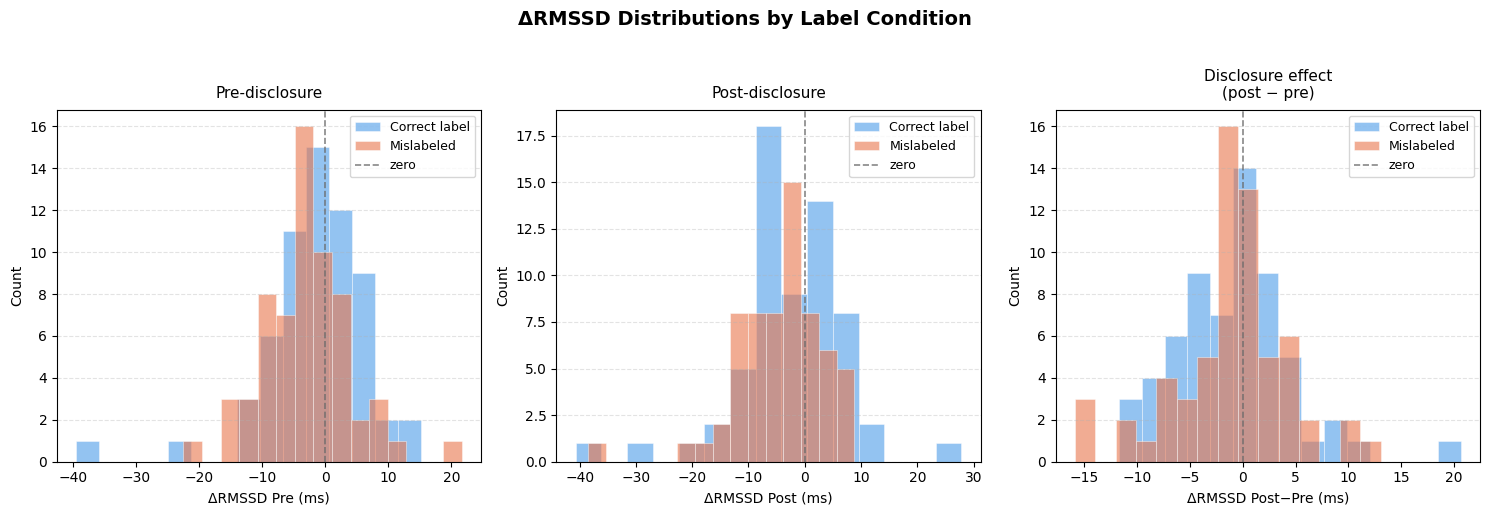

Saved: delta_rmssd_histograms.png


In [18]:
import matplotlib.pyplot as plt

HIST_COLORS = {'Correct label': '#4C9BE8', 'Mislabeled': '#E8754C'}

cols_hist = [
    ('delta_rmssd_pre',  'ΔRMSSD Pre (ms)',       'Pre-disclosure'),
    ('delta_rmssd_post', 'ΔRMSSD Post (ms)',       'Post-disclosure'),
    ('delta_rmssd_diff', 'ΔRMSSD Post−Pre (ms)',   'Disclosure effect\n(post − pre)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ΔRMSSD Distributions by Label Condition', fontsize=14, fontweight='bold', y=1.02)

for ax, (col, xlabel, subtitle) in zip(axes, cols_hist):
    for cond, grp in valid_clean.groupby('label_condition'):
        data = grp[col].dropna()
        ax.hist(
            data, bins=15, alpha=0.6,
            color=HIST_COLORS[cond], label=cond,
            edgecolor='white', linewidth=0.5
        )
    ax.axvline(0, color='dimgray', linestyle='--', linewidth=1.2, alpha=0.8, label='zero')
    ax.set_title(subtitle, fontsize=11, pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(OUT_DIR + '/delta_rmssd_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: delta_rmssd_histograms.png")


## 15. Assumption Checks

Before running the paired t-test, two assumptions must hold:

1. **Normality** (Shapiro-Wilk) — checked on per-participant mean ΔRMSSD and on the difference scores (Correct − Mislabeled).  H₀: data are normally distributed; p > .05 → assumption met. Relatively robust with n > 30.
2. **Homogeneity of variance** (Levene's test) — checked on trial-level ΔRMSSD_post between conditions (for completeness; the paired design already controls for individual differences).  H₀: group variances are equal; p > .05 → equal variances assumed.


In [19]:
import scipy.stats as stats

# Per-participant mean ΔRMSSD post-disclosure per condition
_per_part = (
    valid_clean
    .groupby(['participant_id', 'label_condition'])['delta_rmssd_post']
    .mean()
    .reset_index()
)
_pp_wide = _per_part.pivot(
    index='participant_id', columns='label_condition', values='delta_rmssd_post'
).dropna()

# Difference scores (Correct − Mislabeled) for the paired test
_diff_scores = _pp_wide['Correct label'] - _pp_wide['Mislabeled']

print('=' * 60)
print('ASSUMPTION — Normality (Shapiro-Wilk)')
print('=' * 60)
print(f'\nPer-participant mean ΔRMSSD post-disclosure (n = {len(_pp_wide)}):')
for cond in ['Correct label', 'Mislabeled']:
    w, p = stats.shapiro(_pp_wide[cond])
    tag = '✓ Normal (p > .05)' if p > .05 else '✗ Non-normal (p < .05)'
    print(f'  {cond:<18}: W = {w:.3f},  p = {p:.3f}  →  {tag}')

w_d, p_d = stats.shapiro(_diff_scores)
tag_d = '✓ Normal (p > .05)' if p_d > .05 else '✗ Non-normal (p < .05)'
print(f'\n  Difference scores   : W = {w_d:.3f},  p = {p_d:.3f}  →  {tag_d}')

print()
print('=' * 60)
print('ASSUMPTION — Homogeneity of Variance (Levene\'s Test)')
print('=' * 60)
lev_stat, lev_p = stats.levene(
    _pp_wide['Correct label'].values,
    _pp_wide['Mislabeled'].values
)
lev_tag = '✓ Equal variances (p > .05)' if lev_p > .05 else '✗ Unequal variances (p < .05)'
print(f'\n  Levene\'s F = {lev_stat:.3f},  p = {lev_p:.3f}  →  {lev_tag}')

if p_d > .05:
    print('\n  → Assumptions met. Paired t-test is appropriate.')
else:
    print('\n  → Normality violated. Consider Wilcoxon signed-rank test as non-parametric alternative.')


ASSUMPTION — Normality (Shapiro-Wilk)

Per-participant mean ΔRMSSD post-disclosure (n = 21):
  Correct label     : W = 0.951,  p = 0.356  →  ✓ Normal (p > .05)
  Mislabeled        : W = 0.914,  p = 0.067  →  ✓ Normal (p > .05)

  Difference scores   : W = 0.966,  p = 0.647  →  ✓ Normal (p > .05)

ASSUMPTION — Homogeneity of Variance (Levene's Test)

  Levene's F = 1.013,  p = 0.320  →  ✓ Equal variances (p > .05)

  → Assumptions met. Paired t-test is appropriate.


## 16. Paired t-test: Correct Label vs. Mislabeled

**Design note:** This is a within-subjects design — each participant experienced both correct and mislabeled trials. A paired t-test is therefore more appropriate than an independent-samples test because it controls for individual differences in resting HRV.

Per-participant means are computed first, then the paired comparison is applied on those aggregated values.

- **Primary DV:** ΔRMSSD post-disclosure (relative to fixation baseline)
- **Secondary DV:** ΔRMSSD Post−Pre (the *change* attributable to the label appearing)

Cohen's d for paired tests = mean(difference) / SD(difference).


In [21]:
import scipy.stats as stats
import numpy as np

def _effect_label(d_abs):
    if d_abs < 0.2:  return 'negligible'
    if d_abs < 0.5:  return 'small'
    if d_abs < 0.8:  return 'medium'
    return 'large'

def _run_paired_ttest(dv_col, dv_name):
    pp = (
        valid_clean
        .groupby(['participant_id', 'label_condition'])[dv_col]
        .mean()
        .reset_index()
        .pivot(index='participant_id', columns='label_condition', values=dv_col)
        .dropna()
    )
    correct    = pp['Correct label'].values
    mislabeled = pp['Mislabeled'].values
    diff       = correct - mislabeled
    n          = len(diff)
    t_stat, p_val = stats.ttest_rel(correct, mislabeled)
    cohens_d   = diff.mean() / diff.std(ddof=1)

    print(f"\n{'─' * 60}")
    print(f'  DV: {dv_name}')
    print(f"{'─' * 60}")
    print(f'  n participants    : {n}')
    print(f'  Correct label     : M = {correct.mean():.2f} ms,  SD = {correct.std(ddof=1):.2f} ms')
    print(f'  Mislabeled        : M = {mislabeled.mean():.2f} ms,  SD = {mislabeled.std(ddof=1):.2f} ms')
    print(f'  Mean difference   : {diff.mean():.2f} ms  (SD = {diff.std(ddof=1):.2f} ms)')
    print()
    print(f'  t({n - 1}) = {t_stat:.3f}')
    print(f"  p = {p_val:.3f}  {'* (significant)' if p_val < .05 else '(not significant)'}")
    print()
    print(f"  Cohen's d = {cohens_d:.3f}  →  {_effect_label(abs(cohens_d))} effect")
    print()
    if p_val < .05:
        direction = 'higher' if diff.mean() > 0 else 'lower'
        print(f'  Interpretation: Post-disclosure ΔRMSSD was significantly {direction}')
        print(f'  in the Correct label condition than in the Mislabeled condition.')
    else:
        print(f'  Interpretation: No significant difference detected between conditions.')
        print(f"  Inspect Cohen's d to assess practical magnitude.")

print('=' * 60)
print('PAIRED t-TEST — ΔRMSSD: Correct Label vs. Mislabeled')
print('=' * 60)

_run_paired_ttest('delta_rmssd_post', 'ΔRMSSD Post-disclosure (primary)')
_run_paired_ttest('delta_rmssd_diff', 'ΔRMSSD Post−Pre / disclosure effect (secondary)')


PAIRED t-TEST — ΔRMSSD: Correct Label vs. Mislabeled

────────────────────────────────────────────────────────────
  DV: ΔRMSSD Post-disclosure (primary)
────────────────────────────────────────────────────────────
  n participants    : 21
  Correct label     : M = -2.35 ms,  SD = 4.16 ms
  Mislabeled        : M = -4.36 ms,  SD = 3.60 ms
  Mean difference   : 2.01 ms  (SD = 5.79 ms)

  t(20) = 1.588
  p = 0.128  (not significant)

  Cohen's d = 0.347  →  small effect

  Interpretation: No significant difference detected between conditions.
  Inspect Cohen's d to assess practical magnitude.

────────────────────────────────────────────────────────────
  DV: ΔRMSSD Post−Pre / disclosure effect (secondary)
────────────────────────────────────────────────────────────
  n participants    : 21
  Correct label     : M = -0.83 ms,  SD = 3.22 ms
  Mislabeled        : M = -1.22 ms,  SD = 3.31 ms
  Mean difference   : 0.38 ms  (SD = 4.04 ms)

  t(20) = 0.432
  p = 0.670  (not significant)

  Cohe